In [27]:
'''
Plots for paper 2: M8 letter
Date: Jan 8th, 2026
Author: Amrita Singh (some part of plot 3 is written by Guillermo Blanc)

This will contain plots created using theory and observations 
'''

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table
import os
import ipympl
import warnings
from astropy.utils.exceptions import AstropyUserWarning
from astropy import units as u
import pyneb as pn
from astropy.stats import median_absolute_deviation as mad
from astropy.coordinates import SkyCoord
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.gridspec import GridSpec
# Making x and y ticks more readable
from matplotlib.ticker import MaxNLocator   
# to compress image size
#from PIL import Image
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from sklearn.linear_model import TheilSenRegressor
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.colors import Normalize

from scipy.stats import pearsonr

In [28]:
data_dir ='/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/'

In [29]:
################################## spatially resolved data ###################################

with fits.open(data_dir+f'resolved/lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits') as hdu:
    data = hdu[1].data
    header = hdu[1].header

RA_list = data['obs_RA']
Dec_list =  data['obs_Dec']


with fits.open(data_dir+f'resolved/lagoon_combined_multi_normalized_diagnostics_1.1.2dev0.fits') as hdu:
    diag = hdu[1].data
    header = hdu[1].header

################################## radially binned data ###################################
filename =  data_dir+f'annbinned/annular_binned_obs_corr_flux_1.1.2dev0.fits'
with fits.open(filename) as hdul:
    binned = hdul[1].data
    header = hdul[1].header
    
with fits.open(data_dir+f'annbinned/multi_normalized_lagoon_anbinned_diagnostics_1.1.2dev0.fits') as  hdu:
    diag_binned = hdu[1].data
    header = hdu[1].header

################################### elliptical mask binned ##################################
with fits.open(data_dir+f'ellbinned/mean_multi_normalized_ellipse_masked_annbinned_obs_corr_flux_1.1.2dev0.fits') as hdu:
    header = hdu[1].header
    ell_binned = hdu[1].data


with fits.open(data_dir+f'ellbinned/mean_multi_normalized_ellipse_masked_annularbins_diagnostics_1.1.2dev0.fits') as hdu:
    ell_diag_binned = hdu[1].data
    header = hdu[1].header


############################################ integrated data ########################################

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_integrated_obs_corr_flux_1.1.2dev0.fits') as hdul:
    int_data = hdul[1].data
    header = hdul[1].header
    #print(repr(header))

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_integrated_diagnostics_table_1.1.2dev0.fits') as hdul:
    diag_int = hdul[1].data
    header = hdul[1].header


############################################ elliptical mask integrated data ########################################

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_ellipse_integrated_obs_corr_flux_1.1.2dev0.fits') as hdul:
    ell_int_data = hdul[1].data
    header = hdul[1].header

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_ellipse_integrated_diagnostics_table_1.1.2dev0.fits') as hdul:
    ell_diag_int = hdul[1].data
    header = hdul[1].header

#print(repr(header))

############################################ central spaxel data ########################################

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_central_spaxel_obs_corr_flux_1.1.2dev0.fits') as hdul:
    central_spaxel_data = hdul[1].data
    header = hdul[1].header

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_central_spaxel_diagnostics_table_1.1.2dev0.fits') as hdul:
    central_spaxel_diag = hdul[1].data
    header = hdul[1].header


############################################ TeORL #############################################

hdu =  fits.open(data_dir+f'resolved/lagoon_combined_multi_normalized_TeOrl_from_ratio_and_ne_1.1.2dev0.fits')
datal =  hdu[1].data
te_obs = datal['Te_obs']
te_obs_err = datal['Te_obs_err']
ratio_obs =  datal['Ratio_obs']
ratio_err =  datal['Ratio_err']



with fits.open(data_dir+f'annbinned/multi_normalized_lagoon_anbinned_TeOrl_1.1.2dev0.fits') as hdu:
 
    bins = hdu[1].data

    te_obs_binned =    bins['Te_obs']
    te_obs_err_binned =bins['Te_obs_err']
    ratio_obs_binned = bins['Ratio_obs']
    ratio_err_binned = bins['Ratio_err']

with fits.open(data_dir+f'ellbinned/mean_multi_normalized_lagoon_elliptical_mask_TeOrl_from_ratio_and_ne.fits') as hdu:

    ell_bins = hdu[1].data
    ell_te_obs_binned =    ell_bins['Te_obs']
    ell_te_obs_err_binned =ell_bins['Te_obs_err']
    ell_ratio_obs_binned = ell_bins['Ratio_obs']
    ell_ratio_err_binned = ell_bins['Ratio_err']

with fits.open(data_dir+f'integrated/multi_normalized_ellipse_integrated_TeOrl_1.1.2dev0.fits') as hdu:
    
    ell_int = hdu[1].data
    ell_te_obs_int =    ell_int['Te_obs']
    ell_te_obs_err_int =ell_int['Te_obs_err']
    ell_ratio_obs_int = ell_int['Ratio_obs']
    ell_ratio_err_int = ell_int['Ratio_err']

with fits.open(data_dir+f'integrated/multi_normalized_integrated_TeOrl_1.1.2dev0.fits') as hdu:
    int = hdu[1].data

    te_obs_int =    int['Te_obs']
    te_obs_err_int =int['Te_obs_err']
    ratio_obs_int = int['Ratio_obs']
    ratio_err_int = int['Ratio_err']

with fits.open(data_dir+f'integrated/multi_normalized_lagoon_central_spaxel_TeOrl_1.1.2dev0.fits') as hdu:
    central_spaxel = hdu[1].data

    te_obs_central_spaxel =    central_spaxel['Te_obs']
    te_obs_err_central_spaxel =central_spaxel['Te_obs_err']
    ratio_obs_central_spaxel = central_spaxel['Ratio_obs']
    ratio_err_central_spaxel = central_spaxel['Ratio_err']  

In [30]:
########################### some important measurements ################################
RA_list = data['obs_RA']
Dec_list =  data['obs_Dec']
dr = 1
r_bin = diag_binned['distance']
dist_bin1 = diag_binned['distance'][0]


# spatially resolved
oii_sum =data['int_NII_OII_flux3']+data['int_NII_OII_flux4']+data['int_NII_OII_flux5']+data['int_NII_OII_flux6']+data['int_NII_OII_flux8']+data['int_NII_OII_flux9'] #-1.37*data['int_NII_OII_flux1']

oii_sum_err =np.sqrt(data['int_NII_OII_flux3_err']**2+data['int_NII_OII_flux4_err']**2+data['int_NII_OII_flux5_err']**2+
                     data['int_NII_OII_flux6_err']**2+data['int_NII_OII_flux8_err']**2+data['int_NII_OII_flux9_err']**2) #-1.37*data['int_NII_OII_flux1']

oiii_5007 =data['int_[OIII]5007_flux0']
oiii_4363 =data['int_[OIII]4363_flux1']
oiii_4363_err =data['int_[OIII]4363_flux1_err']

hb =data['int_Hb4861_flux0']

snr_orl = (data['int_NII_OII_flux5']+data['int_NII_OII_flux6'])/np.sqrt(data['int_NII_OII_flux5_err']**2+data['int_NII_OII_flux6_err']**2)
snr_cel = data['int_[OIII]4363_flux1']/data['int_[OIII]4363_flux1_err']

# annular binned
oii_sum_binned = binned['int_NII_OII_flux3']+binned['int_NII_OII_flux4']+binned['int_NII_OII_flux5']+binned['int_NII_OII_flux6']+binned['int_NII_OII_flux8']+binned['int_NII_OII_flux9']#-1.37*binned['int_NII_OII_flux1']

oii_sum_binned_err = np.sqrt(binned['int_NII_OII_flux3_err']**2+binned['int_NII_OII_flux4_err']**2+binned['int_NII_OII_flux5_err']**2+
                         binned['int_NII_OII_flux6_err']**2+binned['int_NII_OII_flux8_err']**2+binned['int_NII_OII_flux9_err']**2)#-1.37*binned['int_NII_OII_flux1']

oiii_5007_binned = binned['int_[OIII]5007_flux0']
oiii_4363_binned = binned['int_[OIII]4363_flux1']
oiii_4363_binned_err = binned['int_[OIII]4363_flux1_err']

hb_binned = binned['int_Hb4861_flux0']

snr_orl_binned = binned['int_NII_OII_flux5']+binned['int_NII_OII_flux6']/np.sqrt(binned['int_NII_OII_flux5_err']**2+binned['int_NII_OII_flux6_err']**2)
snr_cel_binned = binned['int_[OIII]4363_flux1']/binned['int_[OIII]4363_flux1_err']

# elliptical annular binned
ell_oii_sum_binned = ell_binned['int_NII_OII_flux3']+ell_binned['int_NII_OII_flux4']+ell_binned['int_NII_OII_flux5']+\
ell_binned['int_NII_OII_flux6']+ell_binned['int_NII_OII_flux8']+ell_binned['int_NII_OII_flux9']#-1.37*binned['int_NII_OII_flux1']

ell_oii_sum_binned_err = np.sqrt(ell_binned['int_NII_OII_flux3_err']**2+ell_binned['int_NII_OII_flux4_err']**2+ell_binned['int_NII_OII_flux5_err']**2+\
                         ell_binned['int_NII_OII_flux6_err']**2+ell_binned['int_NII_OII_flux8_err']**2+ell_binned['int_NII_OII_flux9_err']**2)#-1.37*binned['int_NII_OII_flux1']

ell_oiii_5007_binned = ell_binned['int_[OIII]5007_flux0']
ell_oiii_4363_binned = ell_binned['int_[OIII]4363_flux1']
ell_oiii_4363_binned_err = ell_binned['int_[OIII]4363_flux1_err']

ell_hb_binned = ell_binned['int_Hb4861_flux0']

ell_snr_orl_binned = ell_binned['int_NII_OII_flux5']+ell_binned['int_NII_OII_flux6']/np.sqrt(ell_binned['int_NII_OII_flux5_err']**2+ell_binned['int_NII_OII_flux6_err']**2)
ell_snr_cel_binned = ell_binned['int_[OIII]4363_flux1']/ell_binned['int_[OIII]4363_flux1_err']

# integrated data
oii_sum_int = int_data['int_NII_OII_flux3']+int_data['int_NII_OII_flux4']+int_data['int_NII_OII_flux5']+int_data['int_NII_OII_flux6']+int_data['int_NII_OII_flux8']+int_data['int_NII_OII_flux9']#-1.37*int_data['int_NII_OII_flux1']
oiii_5007_int = int_data['int_[OIII]5007_flux0']
oiii_4363_int = int_data['int_[OIII]4363_flux1']
hb_int = int_data['int_Hb4861_flux0']

oii_sum_int_err = np.sqrt(int_data['int_NII_OII_flux3_err']**2+int_data['int_NII_OII_flux4_err']**2+int_data['int_NII_OII_flux5_err']**2+
                          int_data['int_NII_OII_flux6_err']**2+int_data['int_NII_OII_flux8_err']**2+int_data['int_NII_OII_flux9_err']**2)#-1.37*int_data['int_NII_OII_flux1']

oiii_5007_int_err = int_data['int_[OIII]5007_flux0_err']
oiii_4363_int_err = int_data['int_[OIII]4363_flux1_err']
hb_int_err = int_data['int_Hb4861_flux0_err']

snr_orl_int = int_data['int_NII_OII_flux5']+int_data['int_NII_OII_flux6']/np.sqrt(int_data['int_NII_OII_flux5_err']**2+int_data['int_NII_OII_flux6_err']**2)
snr_cel_int = int_data['int_[OIII]4363_flux1']/int_data['int_[OIII]4363_flux1_err']

######################################################## elliptical integrated data  #######################################################
ell_oii_sum_int = ell_int_data['int_NII_OII_flux3']+ell_int_data['int_NII_OII_flux4']+ell_int_data['int_NII_OII_flux5']+\
ell_int_data['int_NII_OII_flux6']+ell_int_data['int_NII_OII_flux8']+ell_int_data['int_NII_OII_flux9']#-1.37*int_data['int_NII_OII_flux1']

ell_oiii_5007_int = ell_int_data['int_[OIII]5007_flux0']
ell_oiii_4363_int = ell_int_data['int_[OIII]4363_flux1']
ell_hb_int = ell_int_data['int_Hb4861_flux0']

ell_oii_sum_int_err = np.sqrt(ell_int_data['int_NII_OII_flux3_err']**2+ell_int_data['int_NII_OII_flux4_err']**2+ell_int_data['int_NII_OII_flux5_err']**2+
                          ell_int_data['int_NII_OII_flux6_err']**2+ell_int_data['int_NII_OII_flux8_err']**2+ell_int_data['int_NII_OII_flux9_err']**2)#-1.37*int_data['int_NII_OII_flux1']

ell_oiii_5007_int_err = ell_int_data['int_[OIII]5007_flux0_err']
ell_oiii_4363_int_err = ell_int_data['int_[OIII]4363_flux1_err']
ell_hb_int_err = ell_int_data['int_Hb4861_flux0_err']

ell_snr_orl_int = ell_int_data['int_NII_OII_flux5']+ell_int_data['int_NII_OII_flux6']/np.sqrt(ell_int_data['int_NII_OII_flux5_err']**2+ell_int_data['int_NII_OII_flux6_err']**2)
ell_snr_cel_int = ell_int_data['int_[OIII]4363_flux1']/ell_int_data['int_[OIII]4363_flux1_err']

######################################################## central spaxel data #######################################################
central_spaxel_oii_sum = central_spaxel_data['int_NII_OII_flux3']+central_spaxel_data['int_NII_OII_flux4']+central_spaxel_data['int_NII_OII_flux5']+\
central_spaxel_data['int_NII_OII_flux6']+central_spaxel_data['int_NII_OII_flux8']+central_spaxel_data['int_NII_OII_flux9']#-1.37*central_spaxel_data['int_NII_OII_flux1']

central_spaxel_oii_sum_err = np.sqrt(central_spaxel_data['int_NII_OII_flux3_err']**2+central_spaxel_data['int_NII_OII_flux4_err']**2+ 
                            central_spaxel_data['int_NII_OII_flux5_err']**2+central_spaxel_data['int_NII_OII_flux6_err']**2+
                            central_spaxel_data['int_NII_OII_flux8_err']**2+central_spaxel_data['int_NII_OII_flux9_err']**2)#-1.37*central_spaxel_data['int_NII_OII_flux1']

central_spaxel_oiii_5007 = central_spaxel_data['int_[OIII]5007_flux0']
central_spaxel_oiii_4363 = central_spaxel_data['int_[OIII]4363_flux1']
central_spaxel_hb = central_spaxel_data['int_Hb4861_flux0']
central_spaxel_oiii_5007_err = central_spaxel_data['int_[OIII]5007_flux0_err']
central_spaxel_oiii_4363_err = central_spaxel_data['int_[OIII]4363_flux1_err']
central_spaxel_hb_err = central_spaxel_data['int_Hb4861_flux0_err']

central_spaxel_snr_orl =  (central_spaxel_data['int_NII_OII_flux5']+central_spaxel_data['int_NII_OII_flux6'])/np.sqrt(central_spaxel_data['int_NII_OII_flux5_err']**2+central_spaxel_data['int_NII_OII_flux6_err']**2)
central_spaxel_snr_cel = central_spaxel_data['int_[OIII]4363_flux1']/central_spaxel_data['int_[OIII]4363_flux1_err']

####################################################### distances #####################################################
r_bin = binned['obs_distance']
ell_r_bin = ell_binned['obs_distance']

####################### compile useful terms ##################### 

teo3cel = diag['TeO3']
teo3rl = te_obs
teo3celerr = diag['TeO3err']
teo3rlerr = te_obs_err
del_te = teo3cel-teo3rl
del_te_err = np.sqrt(teo3celerr**2 + teo3rlerr**2)
nes2 = diag['neS2']
nes2err = diag['neS2err']

# annular binned FOV
teo3cel_bin = diag_binned['TeO3']
teo3rl_bin = te_obs_binned
teo3celerr_bin = diag_binned['TeO3err']
teo3rlerr_bin = te_obs_err_binned
del_te_bin = teo3cel_bin-teo3rl_bin
del_te_err_bin = np.sqrt(teo3celerr_bin**2 + teo3rlerr_bin**2)
nes2_bin = diag_binned['neS2']
nes2err_bin = diag_binned['neS2err']

#intgrated
teo3cel_int = diag_int['TeO3']
teo3rl_int = te_obs_int
teo3celerr_int = diag_int['TeO3err']
teo3rlerr_int = te_obs_err_int
del_te_int = teo3cel_int-teo3rl_int
del_te_err_int = np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2)
nes2_int = diag_int['neS2']
nes2err_int = diag_int['neS2err']

# elliptical mask binned

ell_teo3cel_bin = ell_diag_binned['TeO3']
ell_teo3rl_bin = ell_te_obs_binned
ell_teo3celerr_bin = ell_diag_binned['TeO3err']
ell_teo3rlerr_bin = ell_te_obs_err_binned
ell_del_te_bin = ell_teo3cel_bin-ell_teo3rl_bin
ell_del_te_err_bin = np.sqrt(ell_teo3celerr_bin**2 + ell_teo3rlerr_bin**2)
ell_nes2_bin = ell_diag_binned['neS2']
ell_nes2err_bin = ell_diag_binned['neS2err']

# elliptical mask integrated    
ell_teo3cel_int = ell_diag_int['TeO3']
ell_teo3rl_int = te_obs_int
ell_teo3celerr_int = ell_diag_int['TeO3err']
ell_teo3rlerr_int = te_obs_err_int
ell_del_te_int = ell_teo3cel_int-ell_teo3rl_int
ell_del_te_err_int = np.sqrt(teo3celerr_int**2 + teo3rlerr_int**2)
ell_nes2_int = ell_diag_int['neS2']
ell_nes2err_int = ell_diag_int['neS2err']

# central spaxel
central_spaxel_teo3cel = central_spaxel_diag['TeO3']
central_spaxel_teo3rl = te_obs_central_spaxel
central_spaxel_teo3celerr = central_spaxel_diag['TeO3err']
central_spaxel_teo3rlerr = te_obs_err_central_spaxel 
central_spaxel_del_te = central_spaxel_teo3cel-central_spaxel_teo3rl
central_spaxel_del_te_err = np.sqrt(central_spaxel_teo3celerr**2 + central_spaxel_teo3rlerr**2)

####################################### elemental abundance of O ############################
def elemental_abund_O(resolved_opp, resolved_opp_err, binned_opp, binned_opp_err, ell_binned_opp, ell_binned_opp_err, resolved_op, resolved_op_err, binned_op, 
                      binned_op_err, ell_binned_op, ell_binned_op_err, int_opp, int_op, ell_int_opp, ell_int_op, central_spaxel_opp, central_spaxel_op, central_spaxel_opp_err, central_spaxel_op_err):
    
    elemental_abund_o = 12 + np.log10(10 ** (resolved_opp - 12) + 10 ** (resolved_op - 12))
    elemental_abund_o_err = np.sqrt(resolved_opp_err**2 + resolved_op_err**2)

    bin_elemental_abund_o = 12 + np.log10(10 ** (binned_opp - 12) + 10 ** (binned_op - 12))
    bin_elemental_abund_o_err = np.sqrt(binned_opp_err**2 + binned_op_err**2)

    ell_bin_elemental_abund_o  = 12 + np.log10(10 ** (ell_binned_opp - 12) + 10 ** (ell_binned_op - 12))
    ell_bin_elemental_abund_o_err = np.sqrt(ell_binned_opp_err**2 + ell_binned_op_err**2)

    int_elemental_abund_o = 12 + np.log10(10 ** (int_opp - 12) + 10 ** (int_op - 12))
    ell_int_elemental_abund_o = 12 + np.log10(10 ** (ell_int_opp - 12) + 10 ** (ell_int_op - 12))

    central_spaxel_elemental_abund_o = 12 + np.log10(10 ** (central_spaxel_opp - 12) + 10 ** (central_spaxel_op - 12))
    central_spaxel_elemental_abund_o_err = np.sqrt(central_spaxel_opp_err**2 + central_spaxel_op_err**2)

    return elemental_abund_o, elemental_abund_o_err, ell_bin_elemental_abund_o, ell_bin_elemental_abund_o_err, \
bin_elemental_abund_o, bin_elemental_abund_o_err, int_elemental_abund_o, ell_int_elemental_abund_o, central_spaxel_elemental_abund_o, central_spaxel_elemental_abund_o_err

ocel, ocelerr, ellocelbin, ellocelbinerr, ocelbin, ocelbinerr, ocelint, ellocelint, cenocel, cenocelerr = elemental_abund_O(diag['Opp_cel'], diag['Opp_cel_err'], diag_binned['Opp_cel'], diag_binned['Opp_cel_err'], 
                  ell_diag_binned['Opp_cel'], ell_diag_binned['Opp_cel_err'], diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], 
                  diag_binned['Op_cel_err'], ell_diag_binned['Op_cel'], ell_diag_binned['Op_cel_err'],  diag_int['Opp_cel'], diag_int['Op_cel'], 
                  ell_diag_int['Opp_cel'], ell_diag_int['Op_cel'], central_spaxel_diag['Opp_cel'], central_spaxel_diag['Op_cel'], central_spaxel_diag['Opp_cel_err'], central_spaxel_diag['Op_cel_err'])

orl, orlerr, ellorlbin, ellorlbinerr, orlbin, orlbinerr, orlint, ellorlint, cenorl, cenorlerr = elemental_abund_O(diag['Opp_RL'], diag['Opp_RL_err'], diag_binned['Opp_RL'], diag_binned['Opp_RL_err'], 
                  ell_diag_binned['Opp_RL'], ell_diag_binned['Opp_RL_err'], diag['Op_cel'], diag['Op_cel_err'], diag_binned['Op_cel'], 
                  diag_binned['Op_cel_err'], ell_diag_binned['Op_cel'], ell_diag_binned['Op_cel_err'],  diag_int['Opp_RL'], diag_int['Op_cel'], 
                  ell_diag_int['Opp_RL'], ell_diag_int['Op_cel'], central_spaxel_diag['Opp_RL'], central_spaxel_diag['Op_cel'], central_spaxel_diag['Opp_RL_err'], central_spaxel_diag['Op_cel_err'])

def calculate_adf(Opp_cel, Opp_rl, Opp_cel_err, Opp_rl_err):
 
    Opp_RL_abund_linear = 10**(Opp_rl - 12) 
    Opp_cel_linear = 10**(Opp_cel - 12)

    # errors to linear scale
    Opp_RL_abund_linear_err = Opp_RL_abund_linear * np.log(10) * Opp_rl_err
    Opp_cel_linear_err = Opp_cel_linear * np.log(10) * Opp_cel_err

    # ADF in linear scale
    ADF_linear = Opp_RL_abund_linear / Opp_cel_linear

    # error on ADF in linear scale
    ADF_linear_err = ADF_linear * np.sqrt((Opp_RL_abund_linear_err / Opp_RL_abund_linear)**2 + 
                                          (Opp_cel_linear_err / Opp_cel_linear)**2)
 
    # ADF and its error back to logarithmic scale
    dex = np.log10(ADF_linear)
    err_dex = ADF_linear_err / (ADF_linear * np.log(10))

    return dex, err_dex


res_adf, res_adf_err = calculate_adf(diag['Opp_cel'], diag['Opp_RL'], diag['Opp_cel_err'], diag['Opp_RL_err'])
adf_bin, adf_err_bin = calculate_adf(diag_binned['Opp_cel'], diag_binned['Opp_RL'], diag_binned['Opp_cel_err'], diag_binned['Opp_RL_err'])
adf_int, adf_err_int = calculate_adf(diag_int['Opp_cel'], diag_int['Opp_RL'], diag_int['Opp_cel_err'], diag_int['Opp_RL_err'])
ell_adf_bin, ell_adf_err_bin = calculate_adf(ell_diag_binned['Opp_cel'], ell_diag_binned['Opp_RL'], ell_diag_binned['Opp_cel_err'], ell_diag_binned['Opp_RL_err'])
ell_adf_int, ell_adf_err_int = calculate_adf(ell_diag_int['Opp_cel'], ell_diag_int['Opp_RL'], ell_diag_int['Opp_cel_err'], ell_diag_int['Opp_RL_err'])

central_spaxel_adf, central_spaxel_adf_err = calculate_adf(central_spaxel_diag['Opp_cel'], central_spaxel_diag['Opp_RL'], central_spaxel_diag['Opp_cel_err'], central_spaxel_diag['Opp_RL_err'])

In [7]:
# Figure 1 of the paper : rgb plot + maps

fig = plt.figure(figsize=(10, 5))
gs = GridSpec(2, 4, figure=fig, width_ratios=[2, 1, 1, 1], wspace=0.008, hspace=0.06)


# Big RGB panel
ax_rgb = fig.add_subplot(gs[:, 0])

# Top row
ax_oppcel = fig.add_subplot(gs[0, 1])
ax_opprl  = fig.add_subplot(gs[0, 2])
ax_adf    = fig.add_subplot(gs[0, 3])

# Bottom row
ax_teo3cel = fig.add_subplot(gs[1, 1])
ax_teo3rl  = fig.add_subplot(gs[1, 2])
ax_delte   = fig.add_subplot(gs[1, 3])

img = plt.imread(data_dir+'m8_rgb_w_stars.png')
oppcel = plt.imread(data_dir+'paper_plots/map_oppcel.png')
opprl = plt.imread(data_dir+'paper_plots/map_opprl.png')
teo3cel = plt.imread(data_dir+'paper_plots/map_teo3cel.png')
teo3rl = plt.imread(data_dir+'paper_plots/map_teo3rl.png')
del_te = plt.imread(data_dir+'paper_plots/map_delte.png')
adf = plt.imread(data_dir+'paper_plots/map_adf.png')


ax_rgb.imshow(img)
ax_rgb.set_xticks([])
ax_rgb.set_yticks([])

ax_rgb.imshow(img)
ax_oppcel.imshow(oppcel, aspect='auto')
ax_opprl.imshow(opprl, aspect='auto')
ax_adf.imshow(adf, aspect='auto')
ax_teo3cel.imshow(teo3cel, aspect='auto')
ax_teo3rl.imshow(teo3rl, aspect='auto')
ax_delte.imshow(del_te, aspect='auto')

for ax in [ax_rgb, ax_oppcel, ax_opprl, ax_adf,
           ax_teo3cel, ax_teo3rl, ax_delte]:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)   

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig(data_dir+'paper_plots/figure1_paper2_m8_letter.png', dpi=300, bbox_inches='tight', pad_inches=0)
plt.close()


In [8]:
# Theoretical plot based on equations from Peimbert 2013

In [19]:
# Define grid of T0 and t2
t0arr = np.arange(4000, 13000, 1000)    #np.linspace(5000, 15000, 10)     
t2arr = np.arange(0, 0.12, 0.02)    
t0, t2 = np.meshgrid(t0arr, t2arr)

# Equation 10 in Peimbert 2013
tdm=t0*(1+(91300/t0-2.68)*t2/2)

# Equation 10 in Peimbert 2013
trl=t0*(1+(29160/t0-3.095+0.415/(29160/t0+0.415))*t2/2)

plt.figure(figsize=(8, 6))
plt.rcParams.update({
                     'axes.labelsize': '14.0',
                     'axes.linewidth': '1.2',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '12',
                     'legend.fontsize': '9'}) 


In [21]:
# Calculate j4959

# formula for emission coefficient
# j_4959 = h * nu_4959 * A_ul * n_u/nO3
# n_u/nO3 = (8.63e-6 * Omega_ul / g_l) * np.exp(-E_ul/(k * Te)) * ne / (Te**0.5 * A_ul)
# j4959_Peimbert = C4959 * Te**(-0.34) * np.exp(-29160.0/Te)


Omega_ul = 2.223     # collision strength at 10,000K, table 2, lennon ad burke 94
g_l = 3              # lower state stat weight
g_u = 5
A_ul = 6.8e-3       # s^-1, table 3.12, page no. 70
h = 6.626e-27        # erg s
c = 2.9979e10        # cm/s
lambda_4959 = 4958.911e-8 
Te = 10000           

nu_4959 = c / lambda_4959   
E_ul = h * nu_4959   

# Formula after commparing equations 1 and 3
C4959 = 8.63e-6 * (Omega_ul / g_l) * E_ul * A_ul * Te**0.5

print("C4959 =", C4959, "erg s^-1 cm^3")

# as per peimbert
print("Cv1 =", C4959*6.56e-5, "erg s^-1 cm^3")


C4959 = 1.7418877951664743e-17 erg s^-1 cm^3
Cv1 = 1.142678393629207e-21 erg s^-1 cm^3


In [22]:
#================================================================================================================#

# Define grids        
abund_arr = np.array([6.5, 7, 7.5, 8, 8.5, 9, 9.5])  

# emission coeff. (Peimbert 2013 form.)
def j_v1(T):
    # O II multiplet V1 recombination emissivity (T^-0.755)
    return 1.143e-21 * T**(-0.755)

def j_4959(T):
    # nebular [O III] 4959-like emissivity (T^-0.34 * exp(-29160/T))
    return 1.742e-17 * T**(-0.34) * np.exp(-29160.0 / T)

def j_Hb(T):
    # Hbeta recombination emissivity approximation ( T^-0.86), Chb osterbrock table 4.2, page 73
    return 2.71e-23 * T**(-0.86)


# numerical second derivative 
def second_derivative(fun, T, h=None):
    T = np.asarray(T)
    if h is None:
        h = np.maximum(5e-3 * T, 1e-8)  # avoid zero step
    return (fun(T + h) - 2.0 * fun(T) + fun(T - h)) / (h**2)

# Make 3D meshgrids
T0, T2, AB = np.meshgrid(t0arr, t2arr, abund_arr, indexing="ij")

# Compute measured temperatures
Te_dm = T0 * (1.0 + (91300.0 / T0 - 2.68) * T2 / 2.0)
Te_rl = T0 * (1.0 + (29160.0 / T0 - 3.095 + 0.415 / (29160.0 / T0 + 0.415)) * T2 / 2.0)

# precompute at T0
jv1_T0 = j_v1(T0)
j4959_T0 = j_4959(T0)
jHb_T0 = j_Hb(T0)


jv1_pp = second_derivative(j_v1, T0)
j4959_pp = second_derivative(j_4959, T0)
jHb_pp = second_derivative(j_Hb, T0)


# Compute averaged emissivities (Peimbert formalism)
J_v1   = jv1_T0   + 0.5 * T0**2 * jv1_pp   * T2
J_4959 = j4959_T0 + 0.5 * T0**2 * j4959_pp * T2
J_Hb   = jHb_T0   + 0.5 * T0**2 * jHb_pp   * T2



# Compute observed ratios
N_true = 10.0**(AB - 12.0)

R4959_obs = N_true * (J_4959 / J_Hb) 
Rv1_obs   = N_true * (J_v1   / J_Hb) 


# Compute new abundances
N_dm = R4959_obs * (j_Hb(Te_dm) / j_4959(Te_dm))
N_rl = Rv1_obs   * (j_Hb(Te_dm) / j_v1(Te_dm))

AB_dm = 12.0 + np.log10(N_dm)
AB_rl = 12.0 + np.log10(N_rl)


# Flatten cube into 1D arrays for FITS table

cols = [
    fits.Column(name="T0_true",    array=T0.ravel(),    format="E"),
    fits.Column(name="t2_true",    array=T2.ravel(),    format="E"),
    fits.Column(name="Abund_true", array=AB.ravel(),    format="E"),
    fits.Column(name="Te_dm",      array=Te_dm.ravel(), format="E"),
    fits.Column(name="Te_rl",      array=Te_rl.ravel(), format="E"),
    fits.Column(name="Abund_dm",   array=AB_dm.ravel(), format="E"),
    fits.Column(name="Abund_rl",   array=AB_rl.ravel(), format="E"),
]

hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto(data_dir+"cube_te_abund_with_consts_paper3.fits", overwrite=True)

plot_dir = data_dir+'paper_plots/'



In [41]:
# Plot 2 of paper 2

In [31]:
plt.figure(figsize = (8, 7))
plt.rcParams.update({
                     'axes.labelsize': '14.0',
                     'axes.linewidth': '1.2',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '8',
                     'legend.fontsize': '10'}) 

hdul = fits.open("/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/cube_te_abund_with_consts_paper3.fits")
data = hdul[1].data

T0       = data["T0_true"]
t2       = data["t2_true"]
AB_true  = data["Abund_true"]
Te_dm    = data["Te_dm"]
Te_rl    = data["Te_rl"]
AB_dm    = data["Abund_dm"]
AB_rl    = data["Abund_rl"]

# Unique t2 values (grid)
t2_unique = np.unique(t2)
t0_vals = np.unique(T0)


xlim = (0, 2500)
ylim = (0, 0.8)


for val in np.unique(T0):
    mask = (T0 == val)
    delta_te = Te_dm[mask] - Te_rl[mask]
    adf = AB_rl[mask] - AB_dm[mask]

    idx = np.argsort(delta_te)
    x = delta_te[idx]
    y = adf[idx]

    plt.plot(x, y, c='grey', alpha=0.3)

    #  just thhe points inside plotting window 
    visible = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])

    if np.any(visible):
        x_vis = x[visible]
        y_vis = y[visible]

        #rightmost visible point
        x_annot = x_vis[-1]
        y_annot = y_vis[-1]

        plt.text(
            x_annot - 80, y_annot,
            fr"T0={val:.0f} K",
            fontsize=9,
            color='grey',
            alpha=0.8,
            va='top'
        )



sn = [3]  #0, 3, 4
for target_sn in sn:
        sel = (snr_orl > target_sn) & (snr_cel > target_sn)
        binsel = (snr_orl_binned >  target_sn) & (snr_cel_binned >  target_sn)

        
        res_median_delte_err = np.nanmedian(del_te_err[sel])
        res_median_adf_err = np.nanmedian(res_adf_err[sel])

        annular_median_delte_err = np.nanmedian(del_te_err_bin[binsel])
        annular_median_adf_err = np.nanmedian(adf_err_bin[binsel])  

        print(del_te[sel].shape, res_adf[sel].shape)

        plt.scatter(del_te[sel], res_adf[sel], s=3, c='b', alpha =0.2, label = 'Spaxels')  

        plt.errorbar(del_te_bin[binsel], adf_bin[binsel], yerr=adf_err_bin[binsel], xerr=del_te_err_bin[binsel], fmt ='s', mfc='r', mec = 'None', ecolor="r", 
                     alpha = 0.5, label = 'Annular Bins')

plt.scatter(ell_del_te_bin, ell_adf_bin, c='k', s= 80, marker ='h', label = 'NGC 6523 annular bins')
plt.scatter(ell_del_te_int, ell_adf_int, c='c', s= 60, alpha = 0.9, marker ='X', label = 'NGC 6523 average')  
plt.scatter(del_te_int, adf_int, c='orange', s= 50, marker ='D', alpha = 0.9, label = 'M8 average')
plt.scatter(ell_del_te_bin[0], ell_adf_bin[0], c='g', s= 80, marker ='o', label = 'Her 36 + HG region')

#plt.scatter(central_spaxel_del_te, central_spaxel_adf, c='g', s= 80, marker ='o', edgecolor='k', label = 'Her 36 + Hourglass spaxel')

# add mmedian error bars at -
res_x = 270
res_y = 0.7
         
# resolved spaxels           
plt.errorbar(res_x, res_y-0.02,
             xerr=res_median_delte_err, yerr=res_median_adf_err,
             fmt=".", mfc='b', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.02, "Resolved", ha="left", va="baseline")

# annular bins
plt.errorbar(res_x, res_y-0.11,
             xerr=annular_median_delte_err, yerr=annular_median_adf_err,
             fmt="s", mfc='r', mec = 'None', ecolor="r", elinewidth=1.5)

plt.text(res_x+50, res_y-0.11,"Annular bins", ha="left", va="bottom") 

# elliptical bins
plt.errorbar(res_x, res_y-0.14,
             xerr=np.nanmedian(ell_del_te_err_bin), yerr=np.nanmedian(ell_adf_err_bin),
             fmt="h", mfc='k', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.13, "NGC 6523 bins", ha="left", va="top")


#integrated 
plt.errorbar(res_x, res_y-0.18, xerr= del_te_err_int, yerr=adf_err_int,
             fmt="D", mfc='orange', mec = 'None', ecolor="orange", alpha = 0.7, elinewidth=1.5)

plt.text(res_x+50, res_y-0.18, "M8 average", ha="left", va="top")


# elliptical binn integgrated
plt.errorbar(res_x, res_y-0.16, xerr= ell_del_te_err_int, yerr=ell_adf_err_int,
             fmt="X", mfc='c', mec = 'None', ecolor="c", elinewidth=1.5)

plt.text(res_x+50, res_y-0.16, "NGC 6523 average", ha="left", va="top")


# central spaxel 
plt.errorbar(res_x, res_y-0.21, xerr= ell_del_te_err_bin[0], yerr=ell_adf_err_bin[0],
             fmt="o", mfc='g', mec = 'None', ecolor="g", elinewidth=1.5)

plt.text(res_x+50, res_y-0.2, "Her 36 + HG region", ha="left", va="top")

plt.xlabel(r"$\Delta T_e = T_e^{CELs} - T_e^{RLs/CEL}$ [K]") 


plt.ylabel("ADF [dex]")    
plt.ylim(0, 0.8)
plt.xlim(0, 2500)  

#plt.legend(loc='best', framealpha=0.3)
plt.tight_layout()
#plt.savefig(data_dir+f'adf_vs_delta_te_m8_elliptical_bins_snr{sn}_mar25_26.png', dpi=300)
plt.close()

(1838,) (1838,)


In [ ]:
# Same as above just add and calculate a best fit line

(1838,) (1838,)
Resolved valid points: 1834
Binned valid points: 18
Elliptical valid points: 5
Correlation coefficient in resolved spaxels: 0.93, p-value: 0
Correlation coefficient in annular bins: 0.80, p-value: 7.42e-05
Correlation coefficient in elliptical bins: 0.99, p-value: 0.00136


/Users/amritasingh/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/amritasingh/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/amritasingh/miniconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


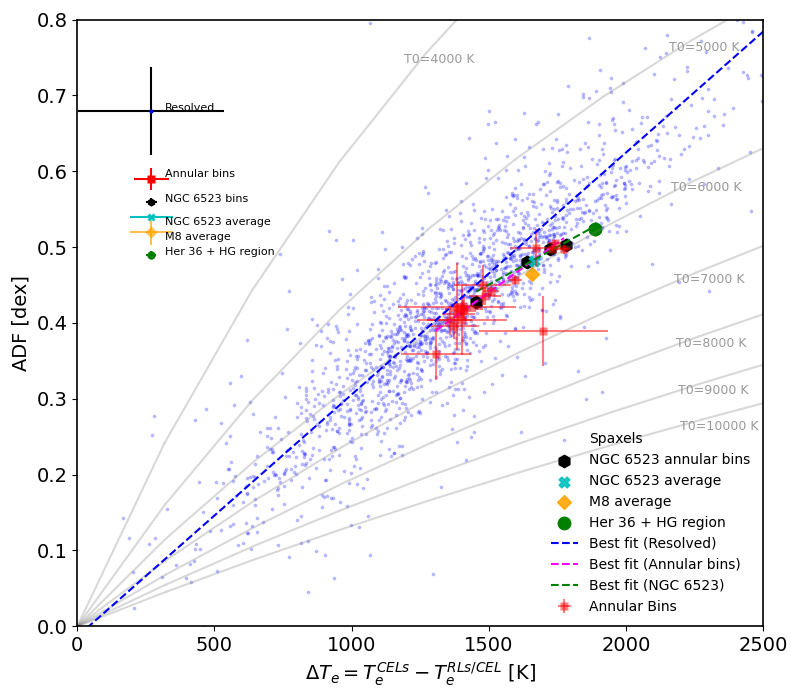

In [73]:
plt.figure(figsize = (8, 7))
plt.rcParams.update({
                     'axes.labelsize': '14.0',
                     'axes.linewidth': '1.2',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '8',
                     'legend.fontsize': '10'}) 

hdul = fits.open("/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/cube_te_abund_with_consts_paper3.fits")
data = hdul[1].data

T0       = data["T0_true"]
t2       = data["t2_true"]
AB_true  = data["Abund_true"]
Te_dm    = data["Te_dm"]
Te_rl    = data["Te_rl"]
AB_dm    = data["Abund_dm"]
AB_rl    = data["Abund_rl"]

# Unique t2 values (grid)
t2_unique = np.unique(t2)
t0_vals = np.unique(T0)


xlim = (0, 2500)
ylim = (0, 0.8)


for val in np.unique(T0):
    mask = (T0 == val)
    delta_te = Te_dm[mask] - Te_rl[mask]
    adf = AB_rl[mask] - AB_dm[mask]

    idx = np.argsort(delta_te)
    x = delta_te[idx]
    y = adf[idx]

    plt.plot(x, y, c='grey', alpha=0.3)

    #  just thhe points inside plotting window 
    visible = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])

    if np.any(visible):
        x_vis = x[visible]
        y_vis = y[visible]

        #rightmost visible point
        x_annot = x_vis[-1]
        y_annot = y_vis[-1]

        plt.text(
            x_annot - 80, y_annot,
            fr"T0={val:.0f} K",
            fontsize=9,
            color='grey',
            alpha=0.8,
            va='top'
        )



sn = [3]  #0, 3, 4
for target_sn in sn:
        sel = (snr_orl > target_sn) & (snr_cel > target_sn)
        binsel = (snr_orl_binned >  target_sn) & (snr_cel_binned >  target_sn)

        
        res_median_delte_err = np.nanmedian(del_te_err[sel])
        res_median_adf_err = np.nanmedian(res_adf_err[sel])

        annular_median_delte_err = np.nanmedian(del_te_err_bin[binsel])
        annular_median_adf_err = np.nanmedian(adf_err_bin[binsel])  

        print(del_te[sel].shape, res_adf[sel].shape)

        plt.scatter(del_te[sel], res_adf[sel], s=3, c='b', alpha =0.2, label = 'Spaxels')  

        plt.errorbar(del_te_bin[binsel], adf_bin[binsel], yerr=adf_err_bin[binsel], xerr=del_te_err_bin[binsel], fmt ='s', mfc='r', mec = 'None', ecolor="r", 
                     alpha = 0.5, label = 'Annular Bins')

plt.scatter(ell_del_te_bin, ell_adf_bin, c='k', s= 80, marker ='h', label = 'NGC 6523 bins')
plt.scatter(ell_del_te_int, ell_adf_int, c='c', s= 60, alpha = 0.9, marker ='X', label = 'NGC 6523 average')  
plt.scatter(del_te_int, adf_int, c='orange', s= 50, marker ='D', alpha = 0.9, label = 'M8 average')
plt.scatter(ell_del_te_bin[0], ell_adf_bin[0], c='g', s= 80, marker ='o', label = 'Her 36 + HG region')


#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

x, y, x_bin, y_bin, x_ell, y_ell = del_te, res_adf, del_te_bin, adf_bin, ell_del_te_bin, ell_adf_bin

# Valid mask to remove NaN or infinite values
valid_mask = np.isfinite(x[sel]) & np.isfinite(y[sel])
valid_mask_bin = np.isfinite(x_bin[binsel]) & np.isfinite(y_bin[binsel])
valid_mask_ell = np.isfinite(x_ell) & np.isfinite(y_ell)
print(f"Resolved valid points: {np.sum(valid_mask)}")
print(f"Binned valid points: {np.sum(valid_mask_bin)}")
print(f"Elliptical valid points: {np.sum(valid_mask_ell)}")

 #=========================================================================================================#  
#if np.sum(valid_mask) > 1:
if (
np.sum(valid_mask) > 1 and
np.sum(valid_mask_bin) > 1 and
np.sum(valid_mask_ell) > 1):
    
    # Compute Pearson correlation coefficient for resolved spaxels
    corr_coeff, p_value = pearsonr(y[sel][valid_mask], x[sel][valid_mask])
    print(f"Correlation coefficient in resolved spaxels: {corr_coeff:.2f}, p-value: {p_value:.3g}")
    # Compute Pearson correlation coefficient  for binned measurements
    corr_coeff_bin, p_value_bin = pearsonr(y_bin[binsel][valid_mask_bin], x_bin[binsel][valid_mask_bin])
    print(f"Correlation coefficient in annular bins: {corr_coeff_bin:.2f}, p-value: {p_value_bin:.3g}")
    # Compute Pearson correlation coefficient  for ELLIPTICAL binned measurements near Her 36
    corr_coeff_ell, p_value_ell = pearsonr(y_ell[valid_mask_ell], x_ell[valid_mask_ell])
    print(f"Correlation coefficient in elliptical bins: {corr_coeff_ell:.2f}, p-value: {p_value_ell:.3g}")
    
    #=========================================================================================================#  
    # Define x and y
    x_axis = x[sel][valid_mask].reshape(-1, 1)
    y_axis = y[sel][valid_mask].reshape(-1, 1)
    x_axis_bin = x_bin[binsel][valid_mask_bin].reshape(-1, 1)
    y_axis_bin = y_bin[binsel][valid_mask_bin].reshape(-1, 1)
    x_axis_ell = x_ell[valid_mask_ell].reshape(-1, 1)
    y_axis_ell = y_ell[valid_mask_ell].reshape(-1, 1)

    #=========================================================================================================#  

    # Theil-Sen fit for resolved
    model = TheilSenRegressor().fit(x_axis, y_axis)
    slope = model.coef_[0]
    intercept = model.intercept_
    # Theil-Sen fit for binned
    model_bin = TheilSenRegressor().fit(x_axis_bin, y_axis_bin)
    slope_bin = model_bin.coef_[0]
    intercept_bin = model_bin.intercept_
    # Theil-Sen fit for NGC 6523
    model_ell = TheilSenRegressor().fit(x_axis_ell, y_axis_ell)
    slope_ell = model_ell.coef_[0]
    intercept_ell = model_ell.intercept_
    
    #=========================================================================================================#  

    # Compute line fit for resolved data
    x_fit = np.linspace(x_axis.min(), x_axis.max(), 500)
    y_fit = slope * x_fit + intercept
    x_fit_bin = np.linspace(x_axis_bin.min(), x_axis_bin.max(), 500)
    y_fit_bin = slope_bin * x_fit_bin + intercept_bin
    x_fit_ell = np.linspace(x_axis_ell.min(), x_axis_ell.max(), 500)
    y_fit_ell = slope_ell * x_fit_ell + intercept_ell

    #=========================================================================================================#  

    # best fit lines 
    plt.plot(x_fit, y_fit, 'b', linestyle ='--', linewidth=1.5, label='Best fit (Resolved)')
    plt.plot(x_fit_bin, y_fit_bin, c='magenta', linestyle ='--', linewidth=1.5, label='Best fit (Annular bins)')
    plt.plot(x_fit_ell, y_fit_ell, c='g', linestyle ='--', linewidth=1.5, label='Best fit (NGC 6523)')

    #=========================================================================================================#  
    
    # Best fit equations
    #print(fr"Best-fit line equation: {ylabel} = {slope:.4f} * {xlabel} + {intercept:.4f}")
    #print(fr"Best-fit line equation: {ylabel} = {slope_bin:.4f} * {xlabel} + {intercept_bin:.4f}")
    #print(fr"Best-fit line equation: {ylabel} = {slope_ell:.4f} * {xlabel} + {intercept_ell:.4f}")



#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# add mmedian error bars at -
res_x = 270
res_y = 0.7
         
# resolved spaxels           
plt.errorbar(res_x, res_y-0.02,
             xerr=res_median_delte_err, yerr=res_median_adf_err,
             fmt=".", mfc='b', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.02, "Resolved", ha="left", va="baseline")

# annular bins
plt.errorbar(res_x, res_y-0.11,
             xerr=annular_median_delte_err, yerr=annular_median_adf_err,
             fmt="s", mfc='r', mec = 'None', ecolor="r", elinewidth=1.5)

plt.text(res_x+50, res_y-0.11,"Annular bins", ha="left", va="bottom") 

# elliptical bins
plt.errorbar(res_x, res_y-0.14,
             xerr=np.nanmedian(ell_del_te_err_bin), yerr=np.nanmedian(ell_adf_err_bin),
             fmt="h", mfc='k', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.13, "NGC 6523 bins", ha="left", va="top")


#integrated 
plt.errorbar(res_x, res_y-0.18, xerr= del_te_err_int, yerr=adf_err_int,
             fmt="D", mfc='orange', mec = 'None', ecolor="orange", alpha = 0.7, elinewidth=1.5)

plt.text(res_x+50, res_y-0.18, "M8 average", ha="left", va="top")


# elliptical binn integgrated
plt.errorbar(res_x, res_y-0.16, xerr= ell_del_te_err_int, yerr=ell_adf_err_int,
             fmt="X", mfc='c', mec = 'None', ecolor="c", elinewidth=1.5)

plt.text(res_x+50, res_y-0.16, "NGC 6523 average", ha="left", va="top")


# central spaxel 
plt.errorbar(res_x, res_y-0.21, xerr= ell_del_te_err_bin[0], yerr=ell_adf_err_bin[0],
             fmt="o", mfc='g', mec = 'None', ecolor="g", elinewidth=1.5)

plt.text(res_x+50, res_y-0.2, "Her 36 + HG region", ha="left", va="top")

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

plt.xlabel(r"$\Delta T_e = T_e^{CELs} - T_e^{RLs/CEL}$ [K]") 


plt.ylabel("ADF [dex]")    
plt.ylim(0, 0.8)
plt.xlim(0, 2500)  

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

plt.legend(loc='lower right', framealpha=0)
plt.tight_layout()
plt.savefig(data_dir+f'adf_vs_delta_te_m8_elliptical_bins_snr{sn}_with_best_fit_lines.png', dpi=300)
plt.show()



In [ ]:
# 2nd version of above plot, distance color coded

In [32]:
ra_hms = '18 03 40.3201232304'
dec_dms = '-24 22 42.857540472'

coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')
ra_center_deg = coord.ra.deg
dec_center_deg = coord.dec.deg
distance_to_nebula = 1250

angular_distances_deg = np.sqrt(
    ((RA_list - ra_center_deg) * np.cos(np.radians(dec_center_deg)))**2 +
    (Dec_list - dec_center_deg)**2)

angular_distances_rad = angular_distances_deg * (np.pi / 180)
distances_parsec = distance_to_nebula * angular_distances_rad

# Converting angular distances from degrees to arcminutes
angular_distances_arcmin = angular_distances_deg * 60

In [33]:
plt.figure(figsize = (9, 7))
plt.rcParams.update({
                     'axes.labelsize': '14.0',
                     'axes.linewidth': '1.2',
                     'ytick.labelsize': '14',
                     'xtick.labelsize': '14',
                     'font.size': '11',
                     'legend.fontsize': '10'}) 

# cube with theoretical measurements

hdul = fits.open("/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/cube_te_abund_with_consts_paper3.fits")
data = hdul[1].data

T0       = data["T0_true"]
t2       = data["t2_true"]
AB_true  = data["Abund_true"]
Te_dm    = data["Te_dm"]
Te_rl    = data["Te_rl"]
AB_dm    = data["Abund_dm"]
AB_rl    = data["Abund_rl"]

# Unique t2 values (grid)
t2_unique = np.unique(t2)
t0_vals = np.unique(T0)


xlim = (0, 2500)
ylim = (0, 0.8)

#=================================================================================================================================================#
#normalizing the colorbar for all measurements: resolved, binned, ellipse

target_sn = 3
sel = (snr_orl > target_sn) & (snr_cel > target_sn)
binsel = (snr_orl_binned >  target_sn) & (snr_cel_binned >  target_sn)

# distances
r_res = angular_distances_arcmin[sel]
r_bin = binned['obs_distance'][binsel]
r_ell = ell_r_bin

rmin = np.min(r_bin)  # can change to resolved distances as well, I have plot for both
rmax = np.max(r_bin)

norm = Normalize(vmin=rmin, vmax=rmax)
cmap = cm.gist_rainbow  # or plasma/hsv/gist_rainbow

#=================================================================================================================================================#


for val in np.unique(T0):
    mask = (T0 == val)
    delta_te = Te_dm[mask] - Te_rl[mask]
    adf = AB_rl[mask] - AB_dm[mask]

    idx = np.argsort(delta_te)
    x = delta_te[idx]
    y = adf[idx]

    plt.plot(x, y, c='grey', alpha=0.38)

    #  just thhe points inside plotting window 
    visible = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])

    if np.any(visible):
        x_vis = x[visible]
        y_vis = y[visible]

        #rightmost visible point
        x_annot = x_vis[-1]
        y_annot = y_vis[-1]

        plt.text(
            x_annot - 150, y_annot,
            fr"T0={val:.0f} K",
            color='grey',
            alpha=0.8,
            va='top'
        )



sn = [3]  #0, 3, 4
for target_sn in sn:
        sel = (snr_orl > target_sn) & (snr_cel > target_sn)
        binsel = (snr_orl_binned >  target_sn) & (snr_cel_binned >  target_sn)

        
        res_median_delte_err = np.nanmedian(del_te_err[sel])
        res_median_adf_err = np.nanmedian(res_adf_err[sel])

        annular_median_delte_err = np.nanmedian(del_te_err_bin[binsel])
        annular_median_adf_err = np.nanmedian(adf_err_bin[binsel])  

        # spatially resolved measuremenst
        sc1 = plt.scatter(del_te[sel], res_adf[sel],
                  c=r_res, cmap=cmap, norm=norm,
                  s=3, alpha = 0.3)
        
        # snnular binned measurements in the entire FOV

        plt.errorbar(del_te_bin[binsel], adf_bin[binsel], yerr=adf_err_bin[binsel], xerr=del_te_err_bin[binsel], fmt ='s', mfc='None', mec = 'None', ecolor="r", 
                     alpha = 0.12, label = 'Annular Bins')
        
    
        sc2 = plt.scatter(del_te_bin[binsel], adf_bin[binsel],
                  c=r_bin, cmap=cmap, norm=norm,
                  s=60, marker='s', edgecolor='none')
        

#plt.scatter(ell_del_te_bin, ell_adf_bin, c='k', s= 80, marker ='h', label = 'NGC 6523 annular bins')

# annular bins within the ellipse
sc3 = plt.scatter(ell_del_te_bin, ell_adf_bin,
                  c=r_ell, cmap=cmap, norm=norm,
                  s=250, alpha = 0.5, marker='h')

plt.scatter(ell_del_te_int, ell_adf_int, c='c', s= 60, alpha = 0.9, marker ='X', label = 'NGC 6523 average')  
plt.scatter(del_te_int, adf_int, c='orange', s= 50, marker ='D', alpha = 0.9, label = 'M8 average')
plt.scatter(ell_del_te_bin[0], ell_adf_bin[0], c='g', s= 80, marker ='o', label = 'Her 36 + HG region')

#plt.scatter(central_spaxel_del_te, central_spaxel_adf, c='g', s= 80, marker ='o', edgecolor='k', label = 'Her 36 + Hourglass spaxel')

# add mmedian error bars at.....
res_x = 270
res_y = 0.7
         
# resolved spaxels           
plt.errorbar(res_x, res_y-0.02,
             xerr=res_median_delte_err, yerr=res_median_adf_err,
             fmt=".", mfc='b', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.02, "Resolved", ha="left", va="baseline")

# annular bins
plt.errorbar(res_x, res_y-0.11,
             xerr=annular_median_delte_err, yerr=annular_median_adf_err,
             fmt="s", mfc='None', mec = 'None', ecolor="r", elinewidth=1.5)

plt.text(res_x+50, res_y-0.11,"Annular bins", ha="left", va="bottom") 

# elliptical bins
plt.errorbar(res_x, res_y-0.14,
             xerr=np.nanmedian(ell_del_te_err_bin), yerr=np.nanmedian(ell_adf_err_bin),
             fmt="h", mfc='k', mec = 'None', ecolor="k", elinewidth=1.5)

plt.text(res_x+50, res_y-0.13, "NGC 6523 bins", ha="left", va="top")


#integrated 
plt.errorbar(res_x, res_y-0.18, xerr= del_te_err_int, yerr=adf_err_int,
             fmt="D", mfc='orange', mec = 'None', ecolor="orange", alpha = 0.7, elinewidth=1.5)

plt.text(res_x+50, res_y-0.18, "M8 average", ha="left", va="top")


# elliptical binn integgrated
plt.errorbar(res_x, res_y-0.16, xerr= ell_del_te_err_int, yerr=ell_adf_err_int,
             fmt="X", mfc='c', mec = 'None', ecolor="c", elinewidth=1.5)

plt.text(res_x+50, res_y-0.16, "NGC 6523 average", ha="left", va="top")


# central spaxel 
plt.errorbar(res_x, res_y-0.21, xerr= ell_del_te_err_bin[0], yerr=ell_adf_err_bin[0],
             fmt="o", mfc='g', mec = 'None', ecolor="g", elinewidth=1.5)

plt.text(res_x+50, res_y-0.2, "Her 36 + HG region", ha="left", va="top")

plt.xlabel(r"$\Delta T_e = T_e^{CELs} - T_e^{RLs/CEL}$ [K]") 


plt.ylabel("ADF [dex]")    
plt.ylim(0, 0.8)
plt.xlim(0, 2500)  

cbar = plt.colorbar(sc2)       ## change to resolved or elliptical bins as needed
cbar.set_label("Radius [arcmin]")

#plt.legend(loc='best', framealpha=0.3)
plt.tight_layout()
plt.savefig(data_dir+f'adf_vs_delta_te_m8_elliptical_bins_snr{sn}_color_coded_w_bin_dist_v1', dpi=300) #res
plt.close()

In [ ]:
# Plot 2 with a zoom in box to show binned measurements clearly

/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_1143/3401513112.py:188: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


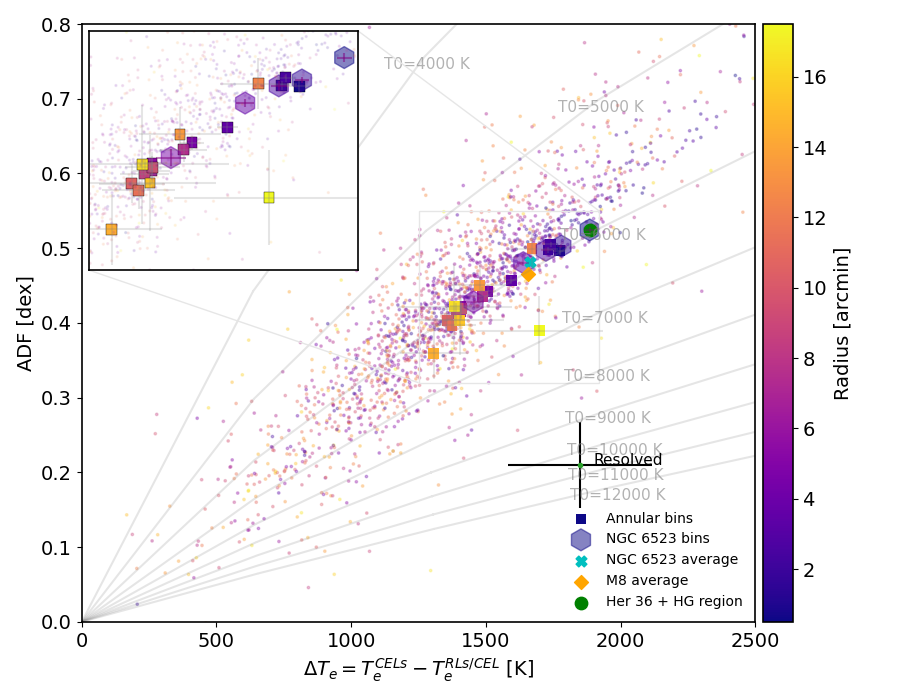

In [34]:


fig, ax = plt.subplots(figsize=(9, 7))

plt.rcParams.update({
    'axes.labelsize': '14.0',
    'axes.linewidth': '1.2',
    'ytick.labelsize': '14',
    'xtick.labelsize': '14',
    'font.size': '11',
    'legend.fontsize': '10'
})

hdul = fits.open("/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/cube_te_abund_with_consts_paper3.fits")
data = hdul[1].data

T0       = data["T0_true"]
t2       = data["t2_true"]
AB_true  = data["Abund_true"]
Te_dm    = data["Te_dm"]
Te_rl    = data["Te_rl"]
AB_dm    = data["Abund_dm"]
AB_rl    = data["Abund_rl"]

# x and y lims
xlim = (0, 2500)
ylim = (0, 0.8)

# colorbar
target_sn = 3
sel = (snr_orl > target_sn) & (snr_cel > target_sn)
binsel = (snr_orl_binned > target_sn) & (snr_cel_binned > target_sn)

r_res = angular_distances_arcmin[sel]
r_bin = binned['obs_distance'][binsel]
r_ell = ell_r_bin

rmin = np.min(r_bin)
rmax = np.max(r_bin)

norm = Normalize(vmin=rmin, vmax=rmax)
cmap = cm.plasma      ################################# can be changes to plama/hsv/gist_rainbow

################################################################### model curves ##################################################################


for val in np.unique(T0):
    mask = (T0 == val)
    delta_te = Te_dm[mask] - Te_rl[mask]
    adf = AB_rl[mask] - AB_dm[mask]

    idx = np.argsort(delta_te)
    x = delta_te[idx]
    y = adf[idx]

    ax.plot(x, y, c='grey', alpha=0.2)

    visible = (x >= xlim[0]) & (x <= xlim[1]) & (y >= ylim[0]) & (y <= ylim[1])

    if np.any(visible):
        ax.text(x[visible][-1] - 150, y[visible][-1],
                fr"T0={val:.0f} K",
                color='grey', alpha=0.6, va='top')

######################################################### resolved and bined data #########################################################
sn = [3]

for target_sn in sn:

    sel = (snr_orl > target_sn) & (snr_cel > target_sn)
    binsel = (snr_orl_binned > target_sn) & (snr_cel_binned > target_sn)

    # resolved
    sc1 = ax.scatter(del_te[sel], res_adf[sel],
                     c=r_res, cmap=cmap, norm=norm,
                     s=3, alpha=0.3)

    # annular bins (error bars)
    ax.errorbar(del_te_bin[binsel], adf_bin[binsel],
                yerr=adf_err_bin[binsel],
                xerr=del_te_err_bin[binsel],
                fmt='s', mfc='None', mec='None',
                ecolor="grey", alpha=0.2)

    # annular bins (scatter points)
    sc2 = ax.scatter(del_te_bin[binsel], adf_bin[binsel],
                     c=r_bin, cmap=cmap, norm=norm,
                     s=60, marker='s', alpha =1, edgecolor='none', label = 'Annular bins')

########################################################################################################################################

##################################################### elliptical bins ####################################################

ax.errorbar(ell_del_te_bin, ell_adf_bin, yerr=ell_adf_err_bin, xerr=ell_del_te_err_bin,
                 fmt='h', mfc='None', mec='None',
                ecolor="purple", alpha=0.3)

sc3 = ax.scatter(ell_del_te_bin, ell_adf_bin,
                 c=r_ell, cmap=cmap, norm=norm,
                 s=250, alpha=0.5, marker='h', label = 'NGC 6523 bins')


##################################################### and average measurements ####################################################

ax.scatter(ell_del_te_int, ell_adf_int, c='c', s=60, marker='X', label='NGC 6523 average')
ax.scatter(del_te_int, adf_int, c='orange', s=50, marker='D', label='M8 average')
ax.scatter(ell_del_te_bin[0], ell_adf_bin[0], c='g', s=80, marker='o', label='Her 36 + HG region')


####################################################### median error bars at #######################################################
res_x, res_y = 1850, 0.23 #270, 0.7

ax.errorbar(res_x, res_y-0.02,
            xerr=np.nanmedian(del_te_err[sel]),
            yerr=np.nanmedian(res_adf_err[sel]),
            fmt=".", ecolor="k")

ax.text(res_x+50, res_y-0.02, "Resolved")

#ax.errorbar(res_x, res_y-0.11,
#            xerr=np.nanmedian(del_te_err_bin[binsel]),
#            yerr=np.nanmedian(adf_err_bin[binsel]),
#            fmt="s", ecolor="r")
#
#ax.text(res_x+50, res_y-0.11, "Annular bins")


####################################################################### zoom window #################################################################

axins = inset_axes(ax, width="40%", height="40%", loc='upper left')

x1, x2 = 1250, 1920
y1, y2 = 0.32, 0.55

axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# annular binned data
axins.scatter(del_te_bin[binsel], adf_bin[binsel],
              c=r_bin, cmap=cmap, norm=norm,
              s=60, marker='s', edgecolor='k', linewidth=0.3)

axins.errorbar(del_te_bin[binsel], adf_bin[binsel],
               yerr=adf_err_bin[binsel],
               xerr=del_te_err_bin[binsel],
               fmt='s', mfc='None', mec='None',
               ecolor="gray", alpha=0.2)

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# elliptical bins
axins.errorbar(ell_del_te_bin, ell_adf_bin, yerr=ell_adf_err_bin, xerr=ell_del_te_err_bin,
                 fmt='h', mfc='None', mec='None',
                ecolor="purple", alpha=0.5)

axins.scatter(ell_del_te_bin, ell_adf_bin,
                 c=r_ell, cmap=cmap, norm=norm,
                 s=250, alpha=0.5, marker='h')

#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%#

# resolved spaxels background
axins.scatter(del_te[sel], res_adf[sel],
              c=r_res, cmap=cmap, norm=norm,
              s=2, alpha=0.1)

#axins.tick_params(labelsize=10)
axins.set_xticks([])
axins.set_yticks([])

# draw box
mark_inset(ax, axins, loc1=3, loc2=1, fc="none", ec="0.9")

####################################################################################################################################################


ax.set_xlabel(r"$\Delta T_e = T_e^{CELs} - T_e^{RLs/CEL}$ [K]")
ax.set_ylabel("ADF [dex]")

ax.set_xlim(xlim)
ax.set_ylim(ylim)


cbar = fig.colorbar(sc2, ax=ax, pad=0.01)  # change to sc1 for resolved distances
cbar.set_label("Radius [arcmin]")


plt.tight_layout()
ax.legend(loc='lower right', framealpha=0.0)
plt.savefig(data_dir + f'adf_vs_delta_te_zoom_inset.png', dpi=300)
plt.show()

In [ ]:
# Plot 3 of paper 2

[0.   0.02 0.04 0.06 0.08 0.1 ]


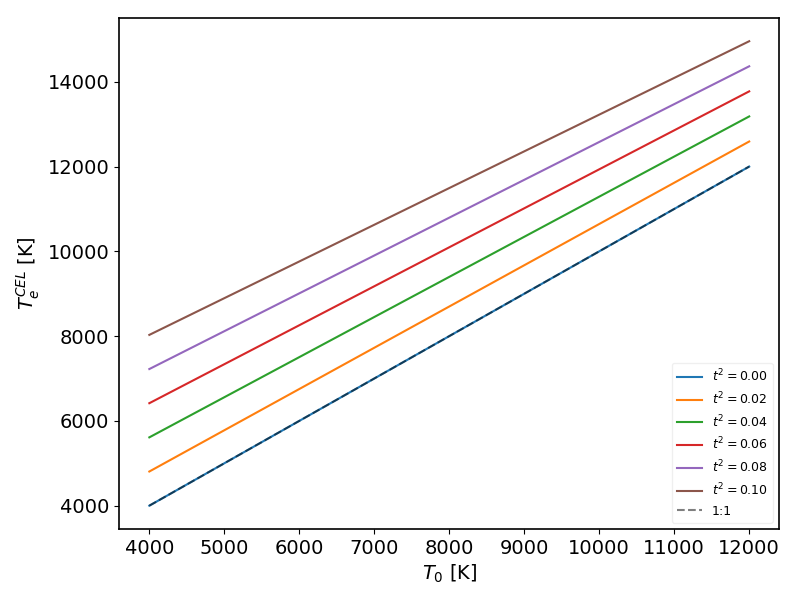

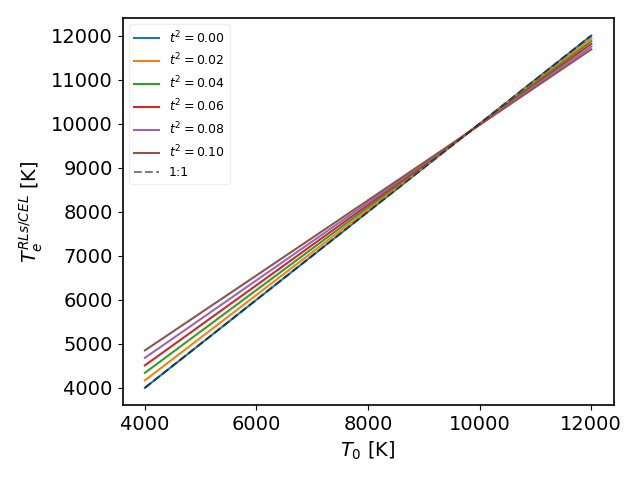

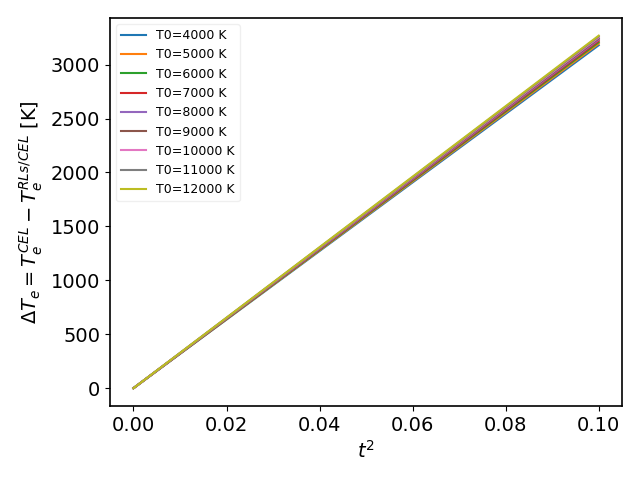

[0. 0. 0. 0. 0. 0. 0.]


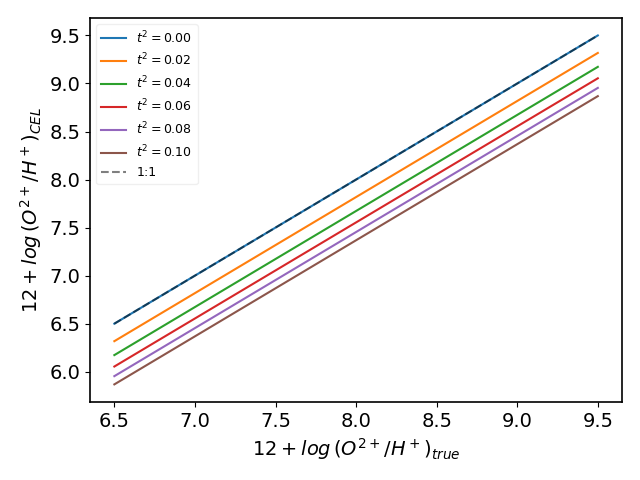

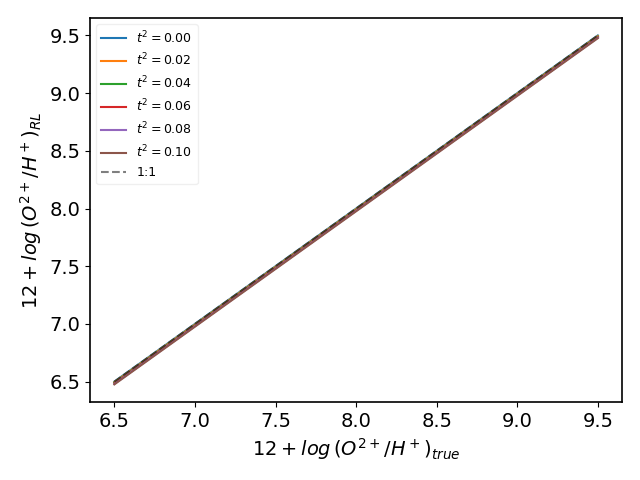

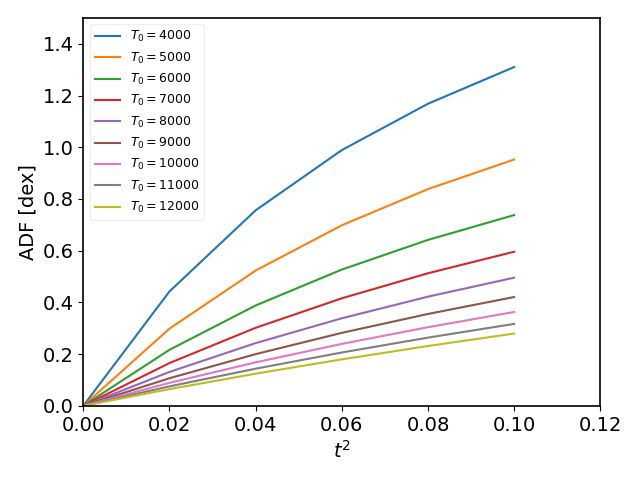

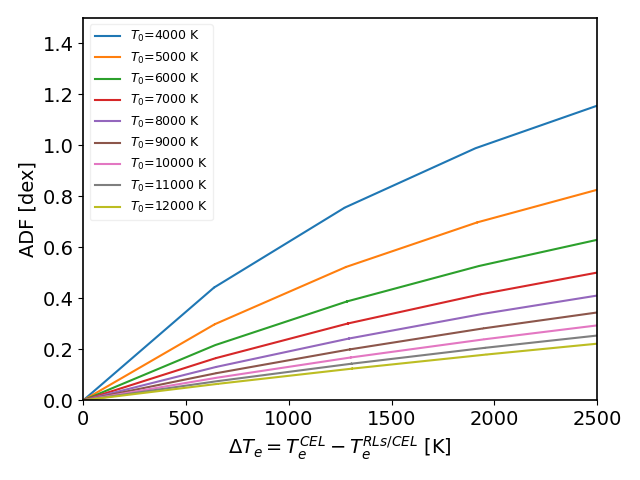

In [23]:


hdul = fits.open(data_dir+"cube_te_abund_with_consts_paper3.fits")
data = hdul[1].data

T0       = data["T0_true"]
t2       = data["t2_true"]
AB_true  = data["Abund_true"]
Te_dm    = data["Te_dm"]
Te_rl    = data["Te_rl"]
AB_dm    = data["Abund_dm"]
AB_rl    = data["Abund_rl"]

# Unique t2 values (grid)
t2_unique = np.unique(t2)

print(t2_unique)    

#=================================================================================================================================================#
#=================================================================================================================================================#

# i. Te_dm vs T0 for each t^2 
for val in t2_unique:
    mask = (t2 == val)
    idx = np.argsort(T0[mask])   # sort by T0

    plt.plot(T0[mask][idx], Te_dm[mask][idx], label=fr"$t^2=${val:.2f}")
#plt.plot(T0, T0, color='black', linestyle='--', alpha=0.5, label='1:1')  # 1:1 line

xline = np.linspace(T0.min(), T0.max(), 100)
plt.plot(xline, xline, color='black', linestyle='--', alpha=0.5, label='1:1')

plt.xlabel(r"$T_0$ [K]")
plt.ylabel(r"$T_e^{CEL}$ [K]")
plt.legend(loc='lower right', framealpha=0.3)
#plt.xlim(4000, 15000)
#plt.ylim(4000, 15000)
##plt.title("i. Te_dm vs T0 for each t^2")
plt.tight_layout()
plt.savefig(plot_dir+'teo3cel_vs_true_te_restricted_range.png', dpi=200)
plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#

# ii. Te_rl vs T0 for each t^2


for val in t2_unique:
    mask = (t2 == val)
    idx = np.argsort(T0[mask])

    plt.plot(T0[mask][idx], Te_rl[mask][idx], label=fr"$t^2=${val:.2f}")
#plt.plot(T0, T0, color='black', linestyle='--', alpha=0.5, label='1:1')  # 1:1 line

xline = np.linspace(T0.min(), T0.max(), 100)
plt.plot(xline, xline, color='black', linestyle='--', alpha=0.5, label='1:1')

plt.xlabel(r"$T_0$ [K]")
plt.ylabel(r"$T_e^{RLs/CEL}$ [K]")
plt.legend(loc='best', framealpha=0.3)
##plt.title("ii. Te_rl vs T0 for each t^2")
plt.tight_layout()
plt.savefig(plot_dir+'teo3rl_vs_true_te_restricted_range.png', dpi=200)

plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#

# v. Te_dm - Te_rl vs t^2

for val in np.unique(T0):
    mask = (T0 == val)
    idx = np.argsort(t2[mask])

    plt.plot(t2[mask][idx], (Te_dm[mask] - Te_rl[mask])[idx], label=f"T0={val:.0f} K")
    
plt.xlabel(r"$t^2$")
plt.ylabel(r"$\Delta T_e = T_e^{CEL} - T_e^{RLs/CEL}$ [K]")
plt.legend(loc='best', framealpha=0.3)
##plt.title("v. Te_dm - Te_rl vs t^2")
plt.tight_layout()
plt.savefig(plot_dir+'delta_te_vs_true_te_restricted_range.png', dpi=200)

plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#

# iii. O++_CEL vs O++_true for each t^2 (fixed)

for val in t2_unique:
    mask = (t2 == val)
    # Group by true abun
    abund_sorted = []
    abund_dm_sorted = []
    for ab in np.unique(AB_true[mask]):
        submask = mask & (AB_true == ab)
        # take mean across T0 values
        abund_sorted.append(ab)
        abund_dm_sorted.append(np.mean(AB_dm[submask]))

    plt.plot(abund_sorted, abund_dm_sorted, label=fr"$t^2={val:.2f}$")
    if val==0:
        print(np.array(abund_sorted) - np.array(abund_dm_sorted))

xline = np.linspace(AB_true.min(), AB_true.max(), 100)
plt.plot(xline, xline, color='black', linestyle='--', alpha=0.5, label='1:1')

plt.xlabel(r"$12+log\, (O^{2+}/H^+)_{true}$")
plt.ylabel(r"$12+log\, (O^{2+}/H^+)_{CEL}$")
plt.legend(loc='best', framealpha=0.3)
#plt.title("iii. O++ CEL vs True abundance for each t^2")
plt.tight_layout()
plt.savefig(plot_dir+'opp_cel_vs_true_restricted_range.png', dpi=200)

plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#

# iv. O++_RL vs O++_true for each t^2 

for val in t2_unique:
    mask = (t2 == val)
    # Group by true abundance
    abund_sorted = []
    abund_rl_sorted = []
    for ab in np.unique(AB_true[mask]):
        submask = mask & (AB_true == ab)
        abund_sorted.append(ab)
        abund_rl_sorted.append(np.mean(AB_rl[submask]))

    plt.plot(abund_sorted, abund_rl_sorted, label=fr"$t^2={val:.2f}$")

#plt.plot(AB_true, AB_true, color='black', linestyle='--', alpha=0.5, label='1:1')  # 1:1 line

xline = np.linspace(AB_true.min(), AB_true.max(), 100)
plt.plot(xline, xline, color='black', linestyle='--', alpha=0.5, label='1:1')

plt.xlabel(r"$12+log\, (O^{2+}/H^+)_{true}$")
plt.ylabel(r"$12+log\, (O^{2+}/H^+)_{RL}$")
plt.legend(loc='best', framealpha=0.3)
plt.tight_layout()
#plt.title("iv. O++ RL vs True abundance for each t^2")
plt.savefig(plot_dir+'opp_rl_vs_true_restricted_range.png', dpi=200)

plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#


# vi. O++_RL - O++_CEL vs t^2 

for t0 in np.unique(T0):
    adf_sorted = []
    t2_sorted = []
    for val in np.unique(t2):
        mask = (T0 == t0) & (t2 == val)
        if np.any(mask):
            adf_sorted.append(np.mean(AB_rl[mask] - AB_dm[mask]))

            #print(AB_dm[mask] - AB_true[mask], t2)
            t2_sorted.append(val)

    plt.plot(t2_sorted, adf_sorted, label=fr"$T_0=${t0:.0f}")

plt.xlabel(r"$t^2$")
plt.ylabel("ADF [dex]")
plt.ylim(0, 1.5)
plt.xlim(0, 0.12)    
plt.legend(loc='best', framealpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir+'adf_vs_t2_restricted_range.png', dpi=200)

plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#


#vii. ADF vs delta te

for val in np.unique(T0):
    mask = (T0 == val)
    delta_te = Te_dm[mask] - Te_rl[mask]
    adf = AB_rl[mask] - AB_dm[mask]
    # Sort by delta_te 
    idx = np.argsort(delta_te)

    plt.plot(delta_te[idx], adf[idx], label=fr"$T_0$={val:.0f} K")
    
plt.xlabel(r"$\Delta T_e = T_e^{CEL} - T_e^{RLs/CEL}$ [K]")
plt.ylabel("ADF [dex]")    
plt.ylim(0, 1.5)
plt.xlim(0, 2500)  
plt.legend(loc='best', framealpha=0.3)
plt.tight_layout()
plt.savefig(plot_dir+'adf_vs_delta_te_restricted_range.png', dpi=200)

plt.show()


In [11]:
# RGB plot for the paper

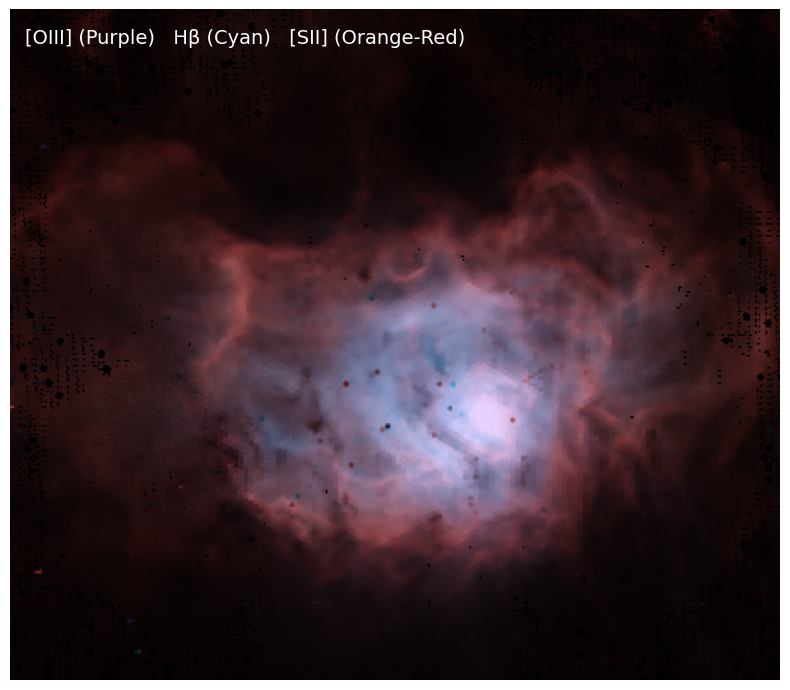

In [8]:

from scipy.ndimage import gaussian_filter
from matplotlib.colors import to_rgb

data_dir = '/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/'

OIII = fits.getdata(data_dir+'lvm_cutout_hips_pm_flux_OIII5007_271.179811_-24.243178_1.76057_600_392.fits').astype(float)
Hb   = fits.getdata(data_dir+'lvm_cutout_hips_pm_flux_Hbeta_271.179811_-24.243178_1.76057_600_392.fits').astype(float)
SII  = fits.getdata(data_dir+'lvm_cutout_hips_pmk_flux_SII6717and31_271.179811_-24.243178_1.76057_600_392.fits').astype(float)

# Replace NaNs
OIII = np.nan_to_num(OIII)
Hb   = np.nan_to_num(Hb)
SII  = np.nan_to_num(SII)


sigma = 0.1  # smoothing


OIII = gaussian_filter(OIII, sigma)
Hb   = gaussian_filter(Hb, sigma)
SII  = gaussian_filter(SII, sigma)

#let's scale a bit
def scale_image(img, Q=8, lower=0.5, upper=99.89):
    vmin = np.percentile(img, lower)
    vmax = np.percentile(img, upper)

    img = np.clip(img, vmin, vmax)

    img = (img - vmin) / (vmax - vmin)

    # arcsinh stretch (preserves faint + bright)
    return np.arcsinh(Q * img) / np.arcsinh(Q)

OIII_s = scale_image(OIII, Q=8)
Hb_s   = scale_image(Hb,   Q=8)
SII_s  = scale_image(SII,  Q=6)


# option 1: hst pallets plots

#c_SII  = np.array(to_rgb('#e63946'))   # red
#c_Hb   = np.array(to_rgb('#2ec4b6'))   #teal
#c_OIII = np.array(to_rgb('#4361ee'))   # blue

#option2

c_SII  = np.array(to_rgb('#d62828'))   # red
c_Hb   = np.array(to_rgb('#2ec4b6'))   # teal,  soft green: #74c69d
c_OIII = np.array(to_rgb('#4361ee'))   #blue


w_SII  = 1.1
w_Hb   = 0.7   # strong reduction
w_OIII = 1.0


# colors
img_SII  = w_SII  * SII_s[..., None]  * c_SII
img_Hb   = w_Hb   * Hb_s[..., None]   * c_Hb
img_OIII = w_OIII * OIII_s[..., None] * c_OIII


rgb = img_Hb + img_OIII + img_SII 

# highlight compression
rgb = rgb / (1 + 0.9* rgb)
rgb = np.clip(rgb, 0, 1)
rgb = rgb / np.max(rgb)

gamma = 0.9
rgb = rgb ** (1/gamma)


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(rgb, origin='lower')

ax.set_xlim(100, 550)
ax.set_axis_off()
ax.text(0.02, 0.95,
        '[OIII] (Purple)   Hβ (Cyan)   [SII] (Orange-Red)',
        transform=ax.transAxes,
        color='white',
        fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
#RGB from fluxes from the fits file

270.91876375 -24.379063333333335


/var/folders/g4/svmgwvyj7c7_qv7_5yns8mzh0000gn/T/ipykernel_46721/2952749310.py:116: RuntimeWarning: invalid value encountered in log10
  OIII_flux = np.log10(table['int_[OIII]5007_flux0']+table['int_[OIII]4959_flux0'])


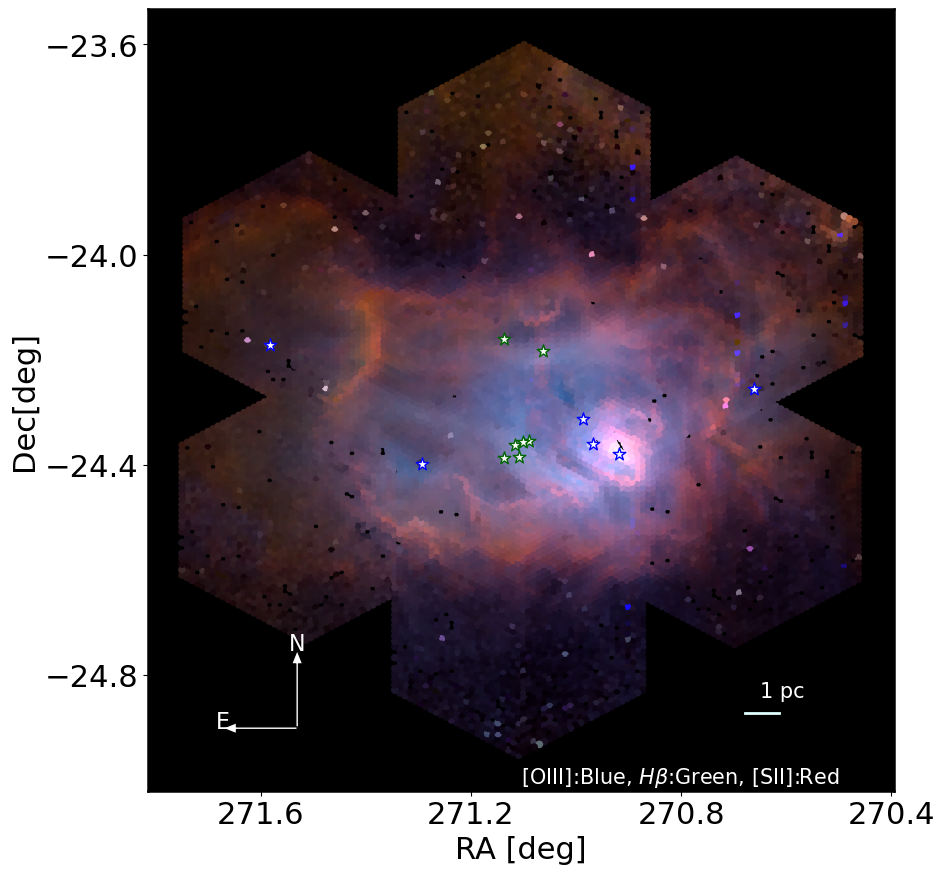

In [23]:
data_dir = '/Users/amritasingh/amrita/M8_oct30_25_final_for_paper/'


with fits.open(data_dir+f'resolved/lagoon_obs_corr_flux_table_1.1.2dev0_jul8.fits') as hdu:
    table = hdu[1].data
    header = hdu[1].header

# Assuming Her 36 binary as center for RA and Dec coordinates
ra_hms = '18 03 40.5033'
dec_dms = '-24 22 44.628'
coord = SkyCoord(ra=ra_hms, dec=dec_dms, unit=(u.hourangle, u.deg), frame='icrs')

# convert ra and dec to deg
ra_center_deg = coord.ra.deg
dec_center_deg = coord.dec.deg

#=================================================================================================================================================#
#=================================================================================================================================================#

#plotting func
def plotmap(c, RA_list, Dec_list, title='M8 Halpha cont Map', ctitle = r'log Flux (erg $s^{-1} cm^{-2} \AA^{-1}$)'):


    plt.rcParams.update({'axes.titlesize': '30',
                 'axes.labelsize':'22',
                 'axes.linewidth':     '1.8' ,
                 'ytick.labelsize': '22',
                 'xtick.labelsize': '22',
                 'font.size': '25.0',
                 'legend.fontsize':'20'})
    
    fig, ax = plt.subplots(figsize=(10, 11))

    sc = ax.scatter(RA_list, Dec_list, facecolors=c, s=20, alpha=1)
    ax.set_aspect('equal', adjustable='box')
    
#=================================================================================================================================================#
#=================================================================================================================================================#

    # Add O-type stars from the FOV
    ax.scatter(ra_center_deg, dec_center_deg, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label ='Hourglass+Her36'
    ax.scatter(270.96852348568,	-24.36074015548, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label ='Srg 9'
    ax.scatter(271.29396932962,	-24.39857822451, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label = 'HD 165052'
    ax.scatter(270.66093137275,	-24.25539096111, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label = 'HD 164536'
    ax.scatter(270.98685232831,	-24.31254042300, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label = 'HD 164816'
    ax.scatter(271.58198590343,	-24.17193699554, s = 90, facecolor = 'w', edgecolor = 'b', alpha =1, marker ='*') #, label = 'HD 165246'
    

    # Add B-type stars from the FOV
    ax.scatter(271.10764805620,	-24.38566030270, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #, label ='HD 164906'
    ax.scatter(271.06339781220,	-24.18336342228, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #, label ='HD 164865'
    ax.scatter(271.11677974740,	-24.36189523491, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #, label ='HD 315031'
    ax.scatter(271.08864833601,	-24.35503903169, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #label = 'CD-24 13829'
    ax.scatter(271.09998130527,	-24.35742817022, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #label = 'CPD-24 6164'
    ax.scatter(271.13746813732,	-24.38680872887, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #label = 'CD-24 13837'    
    ax.scatter(271.13764998076,	-24.16064044863, s = 90, facecolor = 'w', edgecolor = 'darkgreen', alpha =1, marker ='*') #label = 'HD 164933' 

#=================================================================================================================================================#
#=================================================================================================================================================#


    # Create a divider for existing axes instance
    divider = make_axes_locatable(ax)

    ax.set_xlabel("RA [deg]")
    ax.set_ylabel("Dec[deg]")
    ax.set_facecolor('black')
    #ax.set_title(title)
    ax.tick_params(axis='x')
    ax.tick_params(axis='y')
    ax.invert_xaxis()

    # Limit the number of ticks on both axes
    ax.xaxis.set_major_locator(MaxNLocator(nbins=4))  
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  

    
    # Add N and E arrows
    arrow_props = dict(facecolor='white', edgecolor='black', headwidth=8, headlength=10, width=2)
    origin_x, origin_y = 0.2, 0.08
    ax.annotate('', xy=(origin_x, origin_y + 0.1), xytext=(origin_x, origin_y),
                arrowprops=arrow_props, xycoords='axes fraction')
    ax.annotate('', xy=(origin_x - 0.1, origin_y), xytext=(origin_x, origin_y),
                arrowprops=arrow_props, xycoords='axes fraction')
    ax.text(origin_x, origin_y + 0.1, 'N', transform=ax.transAxes, fontsize=16, color='white', ha='center')
    ax.text(origin_x - 0.1, origin_y, 'E', transform=ax.transAxes, fontsize=16, color='white', ha='center')

    # Add scale bar
    nebula_distance = 1250  # in parsecs
    scale_bar_length_pc = 1  # 1 parsec
    scale_bar_length_deg = (scale_bar_length_pc / nebula_distance) * (180 / np.pi)  # convert parsecs to degrees

    ax.plot([0.8, 0.8 + scale_bar_length_deg], [0.1, 0.1], transform=ax.transAxes, color='lightcyan', lw=2)
    ax.text(0.85, 0.12, '1 pc', transform=ax.transAxes, fontsize=15, color='white', ha='center')

    ax.text(0.5, 0.01, r'[OIII]:Blue, $H\beta$:Green, [SII]:Red', transform=ax.transAxes, fontsize=15, color='white', ha='left')

    #plt.legend(loc='upper right', fontsize=18)
    #fig.subplots_adjust(top=0.98, bottom=0.05, left=0.08, right=0.98)
    #plt.savefig(data_dir+title+'.png', dpi = 400, bbox_inches='tight')

    plt.tight_layout()
    #plt.close()
    plt.show()

#=================================================================================================================================================#
#=================================================================================================================================================#

 # Normalize the flux values for the RGB channels
def normalize_flux(flux, vmin=None, vmax=None):
    
    if vmin is None:
        vmin = np.min(flux)
    if vmax is None:
        vmax = np.max(flux)
        
    norm_flux = (flux - vmin) / (vmax - vmin)
    norm_flux[norm_flux < 0] = 0
    norm_flux[norm_flux > 1] = 1
    return norm_flux

#=================================================================================================================================================#
#=================================================================================================================================================#

# Extract flux values and coordinates
OIII_flux = np.log10(table['int_[OIII]5007_flux0']+table['int_[OIII]4959_flux0'])
SII_flux = np.log10(table['int_[SII]6717_flux0']+table['int_[SII]6731_flux0'])
Hb_flux = np.log10(table['int_Hb4861_flux0'])
RA = table['obs_RA']
Dec = table['obs_Dec']

# Normalize the flux values with custom color scaling
OIII_norm = normalize_flux(OIII_flux, vmin=-16.5, vmax=-11)
SII_norm = normalize_flux(SII_flux, vmin=-17, vmax=-12)
Hb_norm = normalize_flux(Hb_flux, vmin=-16, vmax=-9.21)

# Create RGB array
rgb_array = np.zeros((len(RA), 3))
rgb_array[:, 0] = np.power(SII_norm*1.5, 3)  # Red
rgb_array[:, 1] = np.power(Hb_norm*1.9, 2)  # Green
rgb_array[:, 2] = np.power(OIII_norm*1.4, 2.)  # Blue
rgb_array = np.clip(rgb_array, 0, 1)

#=================================================================================================================================================#
#=================================================================================================================================================#

plotmap(rgb_array, RA, Dec, title='Lagoon Nebula on log scale v2', ctitle = r'scale')
